In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
df = pd.read_parquet("data/pm25_complete_model_ready.parquet")

df = df.sort_values(["site_id", "datetime"]).reset_index(drop=True)
df["datetime"] = pd.to_datetime(df["datetime"])
sites = df["site_id"].unique()


# One site to test

In [3]:
site = sites[0]
df_site = df[df["site_id"] == site].copy()

df_site = df_site.dropna(subset=["pm_filled"]).sort_values("datetime")

EXOG = [
    "wind_speed", "wind_dir",
    "smoke_dist_1", "smoke_dist_2", "smoke_dist_3",
    "fire_dist_1", "fire_dist_2", "fire_dist_3"
]
df_site[EXOG] = df_site[EXOG].fillna(df_site[EXOG].mean())  


In [4]:
def make_window_with_exog(pm_series, exog_matrix, window=48):
    X, y = [], []
    for i in range(len(pm_series) - window):
        window_pm = pm_series[i:i+window]
        window_exog = exog_matrix[i:i+window].flatten()
        X.append(np.concatenate([window_pm, window_exog]))
        y.append(pm_series[i+window])
    return np.array(X), np.array(y)

WINDOW = 168
pm = df_site["pm_filled"].values.astype(float)
exog_vals = df_site[EXOG].values.astype(float)

X, y = make_window_with_exog(pm, exog_vals, WINDOW)

In [5]:
N = len(X)

train_end = int(0.7 * N)
valid_end = int(0.85 * N)

X_train = X[:train_end]
y_train = y[:train_end]

X_valid = X[train_end:valid_end]
y_valid = y[train_end:valid_end]

X_test = X[valid_end:]
y_test = y[valid_end:]

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_valid_t = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid_t, y_valid_t), batch_size=64, shuffle=False)


In [7]:
class TNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.1),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

In [8]:
def reset_model_weights(model):
    """
    Reinitializes model parameters in-place.
    Useful before each new hyperparameter experiment.
    """
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

In [9]:
def train_single_model(seed, input_dim):
    """Train a single model with a specific random seed"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create data loaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), 
                             batch_size=64, shuffle=True)
    valid_loader = DataLoader(TensorDataset(X_valid_t, y_valid_t), 
                             batch_size=64, shuffle=False)
    
    model = TNN(input_dim)
    reset_model_weights(model)
    
    loss_fn = nn.HuberLoss(delta=0.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    
    EPOCHS = 30
    patience = 7
    best_valid = float("inf")
    early_stop_counter = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        # Training
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for xb, yb in valid_loader:
                pred = model(xb)
                loss = loss_fn(pred, yb)
                valid_loss += loss.item()
        
        valid_loss /= len(valid_loader)
        scheduler.step(valid_loss)
        
        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model_state = model.state_dict().copy()
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}, best valid: {best_valid:.3f}")
                break

        if epoch % 5 == 0:
            print(f"  Epoch {epoch+1}: Train={train_loss:.3f}, Valid={valid_loss:.3f}")
    
    model.load_state_dict(best_model_state)
    return model


In [10]:
print("="*70)
print("TRAINING ENSEMBLE OF 5 MODELS")
print("="*70)

input_dim = X_train.shape[1]
models = []

for i in range(5):
    print(f"\n{'='*70}")
    print(f"MODEL {i+1}/5 (seed={42+i})")
    print("="*70)
    model = train_single_model(42 + i, input_dim)
    models.append(model)

print("\n" + "="*70)
print("ENSEMBLE TRAINING COMPLETE!")
print("="*70)

TRAINING ENSEMBLE OF 5 MODELS

MODEL 1/5 (seed=42)
  Epoch 1: Train=1.983, Valid=1.018
  Epoch 6: Train=0.714, Valid=0.863
  Epoch 11: Train=0.570, Valid=0.853
  Early stopping at epoch 12, best valid: 0.849

MODEL 2/5 (seed=43)
  Epoch 1: Train=1.970, Valid=0.994
  Epoch 6: Train=0.728, Valid=0.856
  Epoch 11: Train=0.587, Valid=0.880
  Early stopping at epoch 13, best valid: 0.856

MODEL 3/5 (seed=44)
  Epoch 1: Train=1.920, Valid=1.028
  Epoch 6: Train=0.730, Valid=0.876
  Epoch 11: Train=0.587, Valid=0.867
  Epoch 16: Train=0.530, Valid=0.871
  Early stopping at epoch 20, best valid: 0.856

MODEL 4/5 (seed=45)
  Epoch 1: Train=1.898, Valid=0.987
  Epoch 6: Train=0.745, Valid=0.881
  Epoch 11: Train=0.610, Valid=0.861
  Early stopping at epoch 16, best valid: 0.855

MODEL 5/5 (seed=46)
  Epoch 1: Train=1.943, Valid=1.006
  Epoch 6: Train=0.729, Valid=0.873
  Epoch 11: Train=0.573, Valid=0.873
  Early stopping at epoch 13, best valid: 0.873

ENSEMBLE TRAINING COMPLETE!


In [11]:
print("\nGenerating predictions from each model...")
print("-"*70)
ensemble_preds = []

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).squeeze().numpy()
        ensemble_preds.append(preds)
        
        # Individual model performance
        mae_single = np.mean(np.abs(preds - y_test))
        rmse_single = np.sqrt(np.mean((preds - y_test)**2))
        print(f"Model {i+1}: MAE={mae_single:.4f}, RMSE={rmse_single:.4f}")

# Average predictions across all models
preds_test = np.mean(ensemble_preds, axis=0)

# Ensemble performance
mae = np.mean(np.abs(preds_test - y_test))
rmse = np.sqrt(np.mean((preds_test - y_test)**2))

print("\n" + "="*70)
print("FINAL ENSEMBLE RESULTS:")
print("="*70)
print(f"Ensemble MAE:  {mae:.4f}")
print(f"Ensemble RMSE: {rmse:.4f}")
print("="*70)




Generating predictions from each model...
----------------------------------------------------------------------
Model 1: MAE=2.9607, RMSE=3.9253
Model 2: MAE=3.0119, RMSE=3.9363
Model 3: MAE=2.9956, RMSE=3.8590
Model 4: MAE=3.0853, RMSE=4.0720
Model 5: MAE=2.9931, RMSE=3.9736

FINAL ENSEMBLE RESULTS:
Ensemble MAE:  2.8978
Ensemble RMSE: 3.8146


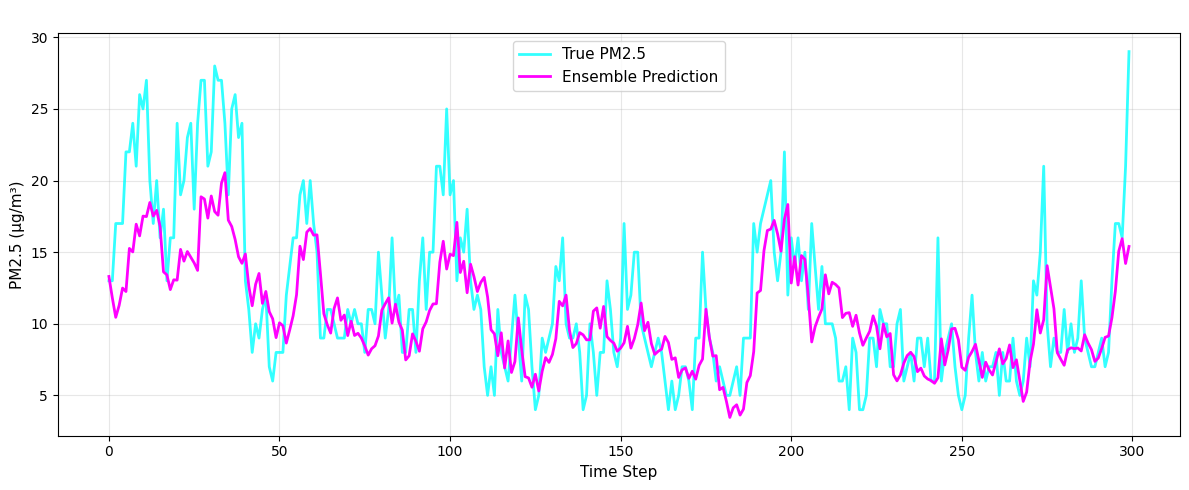

In [12]:
# Plot results
plt.figure(figsize=(12,5))
plt.plot(y_test[-300:], label="True PM2.5", color="cyan", linewidth=2, alpha=0.8)
plt.plot(preds_test[-300:], label="Ensemble Prediction", color="magenta", linewidth=2)
plt.title(f"Ensemble TNN Forecast (5 models) – Site {site}", fontsize=14, color="white")
plt.xlabel("Time Step", fontsize=11)
plt.ylabel("PM2.5 (µg/m³)", fontsize=11)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()